In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("libraries imported successfully!") 

libraries imported successfully!


In [51]:
import os

print("current folder:", os.getcwd())
print("files:", os.listdir())
print("DATA folder:", os.listdir("DATA"))

current folder: D:\Data Science\projects\Customer_Churn_Prediction
files: ['.ipynb_checkpoints', 'app.py', 'Customer churn prediction project.ipynb', 'customer_churn_model.pkl', 'DATA']
DATA folder: ['.ipynb_checkpoints', 'Telco_customer_churn.csv']


In [52]:
df = pd.read_csv("DATA/Telco_customer_churn.csv", encoding="latin1")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [53]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (7043, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 


In [54]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [55]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [56]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [57]:
print(df["Churn Label"].value_counts())

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


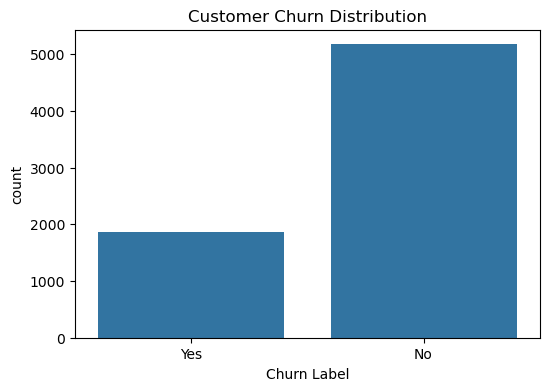

In [58]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn Label", data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [59]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [60]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

df["Total Charges"].dtype

dtype('float64')

In [61]:
df["Total Charges"].isnull().sum()

np.int64(11)

In [62]:
df["Total Charges"].isnull().sum()

np.int64(11)

In [63]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:df[col] = le.fit_transform(df[col])

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,2564,1,0,0,562,90003,327,33.964131,-118.272783,1,...,0,1,3,53.85,108.15,1,1,86,3239,3
1,6511,1,0,0,562,90005,405,34.059281,-118.307420,0,...,0,1,2,70.70,151.65,1,1,67,2701,13
2,6551,1,0,0,562,90006,393,34.048013,-118.293953,0,...,0,1,2,99.65,820.50,1,1,86,5372,13
3,5604,1,0,0,562,90010,410,34.062125,-118.315709,0,...,0,1,2,104.80,3046.05,1,1,84,5003,13
4,174,1,0,0,562,90015,385,34.039224,-118.266293,1,...,0,1,0,103.70,5036.30,1,1,89,5340,2


In [64]:
features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Internet Service",
    "Contract",
    "Monthly Charges",
    "Total Charges"
]

X = df[features]
y = df["Churn Value"]

print(X.head())

   Gender  Senior Citizen  Partner  Dependents  Tenure Months  \
0       1               0        0           0              2   
1       0               0        0           1              2   
2       0               0        0           1              8   
3       0               0        1           1             28   
4       1               0        0           1             49   

   Internet Service  Contract  Monthly Charges  Total Charges  
0                 0         0            53.85         108.15  
1                 1         0            70.70         151.65  
2                 1         0            99.65         820.50  
3                 1         0           104.80        3046.05  
4                 1         0           103.70        5036.30  


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
    )

print("Training Data:", X_train.shape)
print("Testing Data: ", X_test.shape)

Training Data: (5634, 9)
Testing Data:  (1409, 9)


In [66]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model Trained successfully!")

Model Trained successfully!


In [67]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7757274662881476

Confusion Matrix:
[[885 124]
 [192 208]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1009
           1       0.63      0.52      0.57       400

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.77      1409



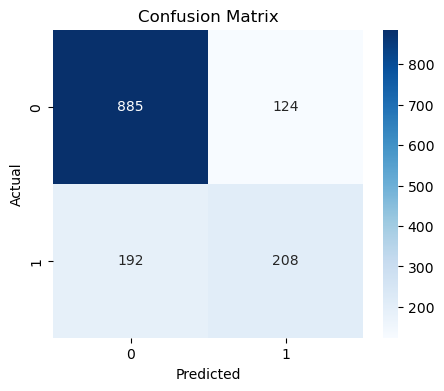

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [69]:
import joblib

joblib.dump(model, "customer_churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [70]:
loaded_model = joblib.load("customer_churn_model.pkl")

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("Customer will Churn")
else:
    print("Customer will Not Churn")

Prediction: [1]
Customer will Churn
